# Regression Discontinuity Design

## Overview

Regression Discontinuity (RD) exploits a threshold rule: units just above a cutoff receive treatment, those just below do not. Near the cutoff, assignment is effectively random — enabling causal identification without full randomisation.

**Two variants:**

| Type | Assignment | Estimand |
|---|---|---|
| Sharp RD | Deterministic at cutoff | Local ATE at cutoff |
| Fuzzy RD | Probability jumps at cutoff | Local LATE (IV-based) |

**Key assumption:** the only discontinuity at the cutoff is the treatment assignment. All other factors (potential outcomes) must be continuous through the cutoff — meaning units cannot precisely sort themselves to one side.

**Local validity:** RD estimates a Local Average Treatment Effect at the cutoff only — it does not generalise to units far from the cutoff.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(42)
n = 800
# Running variable: nitrate index score (continuous)
# Cutoff = 5.0: sites above receive remediation treatment
nitrate_score = rng.uniform(2, 8, n)
cutoff = 5.0
treatment = (nitrate_score >= cutoff).astype(int)
true_LATE = 3.5   # effect at the cutoff
# Smooth potential outcomes + jump at cutoff
Y0 = 22 - 1.2*nitrate_score + 0.1*nitrate_score**2 + rng.normal(0, 1.5, n)
Y1 = Y0 + true_LATE
Y_obs = np.where(treatment==1, Y1, Y0)
df = pd.DataFrame({"score":nitrate_score,"treatment":treatment,"richness":Y_obs})
print(f"n={n}, cutoff={cutoff}, true LATE={true_LATE}")
print(f"Treated (score >= {cutoff}): {treatment.sum()}")

n=800, cutoff=5.0, true LATE=3.5
Treated (score >= 5.0): 395


---
## RD Plot

C:\Users\saman\AppData\Local\Temp\ipykernel_22420\869429126.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = df.groupby("bin")["richness"].mean()
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


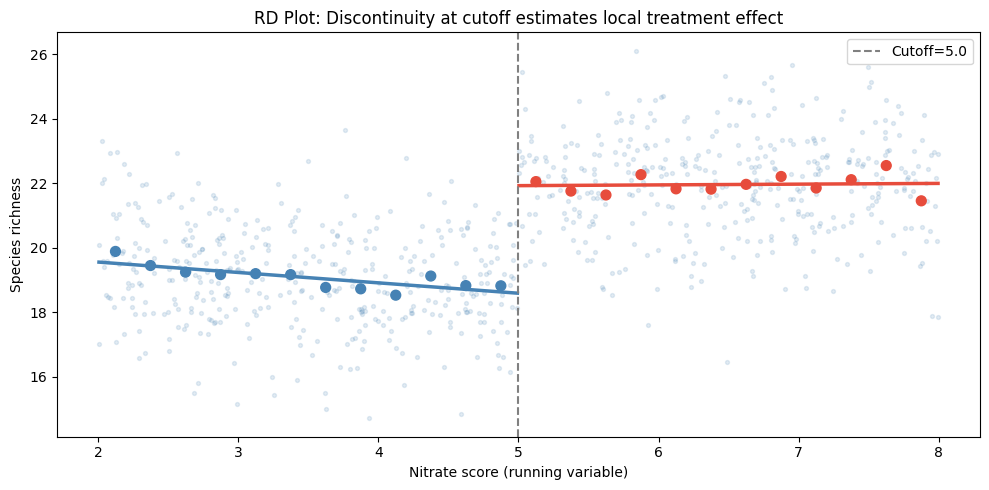

In [2]:
# Bin the running variable and plot means
bins = np.linspace(2, 8, 25)
df["bin"] = pd.cut(df["score"], bins=bins)
bin_means = df.groupby("bin")["richness"].mean()
bin_mids  = [(b.left+b.right)/2 for b in bin_means.index]
fig, ax = plt.subplots(figsize=(10,5))
# Scatter (thin)
ax.scatter(df["score"], df["richness"], alpha=0.15, s=8, color="steelblue")
# Bin means
colors = ["steelblue" if m < cutoff else "#e74c3c" for m in bin_mids]
ax.scatter(bin_mids, bin_means.values, s=50, color=colors, zorder=5)
# Fit separate lines on each side
for mask, color in [(df["score"] < cutoff,"steelblue"),(df["score"] >= cutoff,"#e74c3c")]:
    sub = df[mask]
    lm = LinearRegression().fit(sub[["score"]], sub["richness"])
    x_range = np.linspace(sub["score"].min(), sub["score"].max(), 100).reshape(-1,1)
    ax.plot(x_range, lm.predict(x_range), color=color, lw=2.5)
ax.axvline(cutoff, color="grey", lw=1.5, linestyle="--", label=f"Cutoff={cutoff}")
ax.set_xlabel("Nitrate score (running variable)")
ax.set_ylabel("Species richness")
ax.set_title("RD Plot: Discontinuity at cutoff estimates local treatment effect")
ax.legend(); plt.tight_layout(); plt.show()

---
## RD Estimation: Linear and Polynomial

In [3]:
# Centre the running variable at the cutoff
df["score_c"] = df["score"] - cutoff
results = {}
for label, formula in [
    ("Linear (same slope)",   "richness ~ score_c + treatment"),
    ("Linear (diff slopes)",  "richness ~ score_c*treatment"),
    ("Quadratic",             "richness ~ score_c + I(score_c**2) + treatment"),
]:
    m = smf.ols(formula, df).fit()
    coef = m.params["treatment"]
    ci   = m.conf_int().loc["treatment"]
    results[label] = (coef, ci[0], ci[1])
    print(f"{label:30s}: LATE={coef:.3f} [{ci[0]:.3f},{ci[1]:.3f}]")
print(f"\nTrue LATE: {true_LATE:.3f}")

Linear (same slope)           : LATE=3.366 [2.936,3.796]
Linear (diff slopes)          : LATE=3.341 [2.912,3.769]
Quadratic                     : LATE=3.345 [2.916,3.773]

True LATE: 3.500


---
## Bandwidth Selection

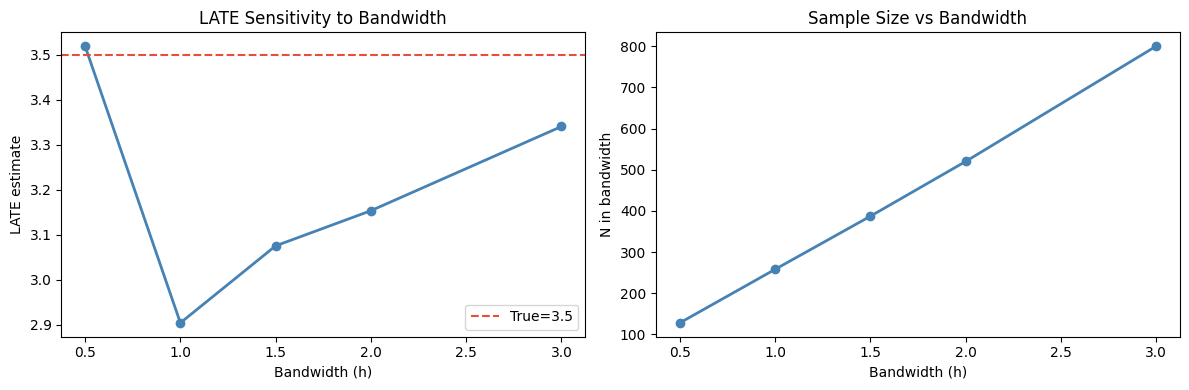

Optimal bandwidth: bias-variance tradeoff
  Narrow h: low bias (local), high variance (few obs)
  Wide h:   high bias (global), low variance (many obs)


In [4]:
# Restrict to observations within a bandwidth h of the cutoff
bandwidths = [0.5, 1.0, 1.5, 2.0, 3.0]
late_estimates = []
late_ns = []
for h in bandwidths:
    sub = df[np.abs(df["score_c"]) <= h]
    m = smf.ols("richness ~ score_c*treatment", sub).fit()
    late_estimates.append(m.params["treatment"])
    late_ns.append(len(sub))
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(bandwidths, late_estimates, "o-", color="steelblue", lw=2)
axes[0].axhline(true_LATE, color="#e74c3c", lw=1.5, linestyle="--", label=f"True={true_LATE}")
axes[0].set_xlabel("Bandwidth (h)"); axes[0].set_ylabel("LATE estimate")
axes[0].set_title("LATE Sensitivity to Bandwidth")
axes[0].legend()
axes[1].plot(bandwidths, late_ns, "o-", color="steelblue", lw=2)
axes[1].set_xlabel("Bandwidth (h)"); axes[1].set_ylabel("N in bandwidth")
axes[1].set_title("Sample Size vs Bandwidth")
plt.tight_layout(); plt.show()
print("Optimal bandwidth: bias-variance tradeoff")
print("  Narrow h: low bias (local), high variance (few obs)")
print("  Wide h:   high bias (global), low variance (many obs)")

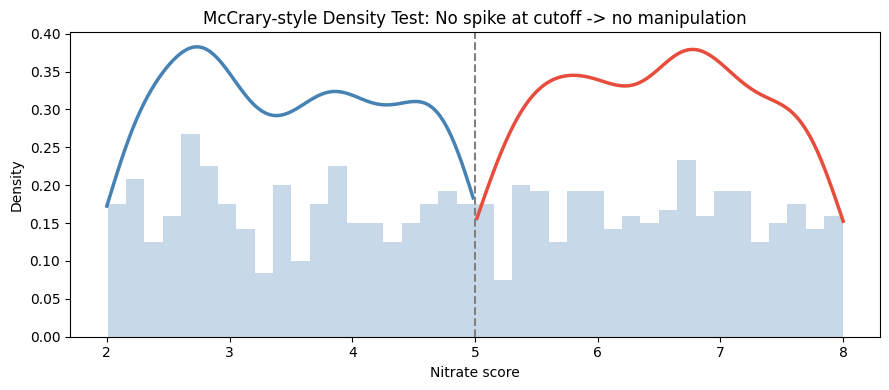

Sharp density discontinuity at cutoff -> units are sorting -> RD invalid
Smooth density through cutoff -> no manipulation -> RD valid


In [5]:
# Manipulation test (McCrary density test)
# Check that units cannot precisely sort around the cutoff
# A spike in density just above the cutoff -> self-selection -> RD invalid
from scipy.stats import gaussian_kde
score_vals = df["score"].values
kde_lo = gaussian_kde(score_vals[score_vals < cutoff])
kde_hi = gaussian_kde(score_vals[score_vals >= cutoff])
x_grid = np.linspace(2, 8, 200)
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(score_vals, bins=40, density=True, alpha=0.3, color="steelblue")
ax.plot(x_grid[x_grid < cutoff], kde_lo(x_grid[x_grid < cutoff]),
        color="steelblue", lw=2.5)
ax.plot(x_grid[x_grid >= cutoff], kde_hi(x_grid[x_grid >= cutoff]),
        color="#e74c3c", lw=2.5)
ax.axvline(cutoff, color="grey", lw=1.5, linestyle="--")
ax.set_xlabel("Nitrate score"); ax.set_ylabel("Density")
ax.set_title("McCrary-style Density Test: No spike at cutoff -> no manipulation")
plt.tight_layout(); plt.show()
print("Sharp density discontinuity at cutoff -> units are sorting -> RD invalid")
print("Smooth density through cutoff -> no manipulation -> RD valid")

---

## Common Pitfalls

**1. Using a global polynomial instead of a local linear estimator**  
Fitting a high-degree polynomial across the full range of the running variable extrapolates heavily away from the cutoff and is sensitive to the polynomial order. Local linear regression within a narrow bandwidth around the cutoff is the recommended approach.

**2. Not testing for density manipulation at the cutoff**  
If units can precisely control the running variable to land on the preferred side of the cutoff, the continuity assumption is violated. Always run a density test (McCrary or Cattaneo-Jansson-Ma) and plot the running variable histogram before trusting the RD estimate.

**3. Choosing the bandwidth arbitrarily rather than by formal selection**  
Bandwidth choice has a large effect on the estimate and its precision. Use the Imbens-Kalyanaraman or Calonico-Cattaneo-Titiunik optimal bandwidth selector (available in the `rdrobust` package in Python/R) rather than choosing by eye.

**4. Testing for covariate jumps at the cutoff only after seeing the outcome results**  
A valid RD should show no discontinuity in pre-treatment covariates at the cutoff. Run the placebo check for all baseline covariates before examining the outcome — running it after inflates the false positive rate.

**5. Extrapolating the RD estimate away from the cutoff**  
RD identifies a local effect at the cutoff for units close to the threshold. Units far from the cutoff may have very different treatment effects. Never interpret an RD estimate as the ATE for the full population.

---
*python_methods_library - Samantha McGarrigle*